# NABirds Bird Species Classification
**SCU — Data Analytics with Python**

## What this notebook does

This notebook trains a fine-tuned **ResNet-50** (PyTorch) to classify bird species from the [NABirds](https://dl.allaboutbirds.org/nabirds) dataset.

NABirds contains roughly **48,000 images** across **555 species / subspecies**. Many classes look very similar (e.g. gulls, sparrows, warblers), so this is a harder fine-grained recognition problem than a typical ImageNet demo.

## Dataset & credits

Data from **[NABirds](https://dl.allaboutbirds.org/nabirds)**, provided by the **[Cornell Lab of Ornithology](https://www.birds.cornell.edu/home/)**, with thanks to photographers and contributors of crowdsourced data at [All About Birds Labs](https://www.allaboutbirds.org/). Supported in part by NSF Grant No. 1010818.

See Van Horn et al., [CVPR 2015](https://openaccess.thecvf.com/content_cvpr_2015/papers/Horn_Building_a_Bird_2015_CVPR_paper.pdf).

## Pipeline at a glance

1. **Load metadata** — image paths, class labels, bounding boxes, and the official train/test split
2. **Explore the data** — class balance and example crops
3. **Carve a validation split from train** — stratified; keep the official test set untouched until the end
4. **Build a PyTorch `Dataset`** — crop to the bird bbox, then apply train / eval transforms
5. **Fine-tune ResNet-50** — keep early layers frozen; train deeper layers + a new classifier head
6. **Checkpoint on validation** — pick the best epoch by val top-1 (with early stopping), then score test once
7. **Interpret with Grad-CAM** — visualize what the model attends to on the hardest vs easiest classes

## How to run

- Designed for **Kaggle** with the dataset mounted at `DATASET_PATH` (see the Configuration section).
- A GPU is strongly recommended for training (up to `NUM_EPOCHS`, often fewer with early stopping).
- If `best_model.pth` already exists in the working directory, the training loop is skipped so you can re-run evaluation / Grad-CAM without retraining.
- After changing the train/val protocol, delete `best_model.pth` and `training_history.csv` and retrain so checkpoints are selected on validation, not an older test-peeking run.

## Exporting results to GitHub

Training needs a GPU (e.g. Kaggle). After a run, download the `images/`, `models/`, and `results/` folders from the Kaggle **Output** sidebar and place them in this repo so others can see metrics and load weights without retraining.


## 1. Import libraries

We use:

- **pandas / numpy** — tabular metadata and numerical arrays
- **PIL** — loading and cropping images
- **PyTorch + torchvision** — model, data loaders, pretrained ResNet-50, and image transforms
- **matplotlib** — EDA plots and Grad-CAM visualizations

Random seeds are set later in Configuration so runs are as reproducible as possible.

In [1]:
import os
from pathlib import Path
import json
import time
import random
from collections import defaultdict

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import FileLink, display

## 2. Configuration

Central place for paths and hyperparameters.

| Setting | Role |
|---|---|
| `DATASET_PATH` / `IMAGE_DIR` | Root of the NABirds folder and its `images/` directory (input data) |
| `IMAGES_OUT` / `MODELS_OUT` / `RESULTS_OUT` | Where plots, weights, and metrics are written (for Kaggle → GitHub) |
| `BATCH_SIZE`, `NUM_WORKERS` | DataLoader throughput |
| `NUM_EPOCHS`, `LR`, `WARMUP_EPOCHS` | Training schedule |
| `VAL_FRACTION` | Fraction of the **official train** split held out for validation / early stopping |
| `EARLY_STOPPING_PATIENCE` | Stop training if validation top-1 does not improve for this many epochs |
| `IMG_SIZE` | Spatial size after transforms (224 for ResNet-50) |
| `SEED` | Reproducibility for PyTorch / NumPy / Python `random` / the val split |
| `DEVICE` | `cuda` → `mps` → `cpu`, whichever is available |

On Kaggle, artifacts land under `/kaggle/working/{images,models,results}/` so you can download them from the Output sidebar and commit them to GitHub.

**Evaluation protocol:** the official NABirds test split is never used for model selection. We checkpoint on validation top-1, then report metrics once on test (saved to `results/final_test_metrics.json`).


In [21]:
DATASET_PATH = "/kaggle/input/datasets/shrutidoshi94/nabirds/nabirds"
IMAGE_DIR = os.path.join(DATASET_PATH, "images")

# Artifact folders (Kaggle Output → copy into the matching GitHub folders)
OUTPUT_ROOT = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path(".")
IMAGES_OUT = OUTPUT_ROOT / "images"
MODELS_OUT = OUTPUT_ROOT / "models"
RESULTS_OUT = OUTPUT_ROOT / "results"
for _dir in (IMAGES_OUT, MODELS_OUT, RESULTS_OUT):
    _dir.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODELS_OUT / "best_model.pth"
METRICS_PATH = RESULTS_OUT / "final_test_metrics.json"
HISTORY_PATH = RESULTS_OUT / "training_history.csv"
PER_CLASS_PATH = RESULTS_OUT / "per_class_accuracy.csv"

BATCH_SIZE = 32
NUM_WORKERS = 4
NUM_EPOCHS = 20
VAL_FRACTION = 0.1
EARLY_STOPPING_PATIENCE = 5
LR = 1e-4
WARMUP_EPOCHS = 2
IMG_SIZE = 224
SEED = 42

DEVICE = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

PIN_MEMORY = DEVICE == "cuda"

torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

print(f"Using device: {DEVICE}")
print(f"Artifacts → {OUTPUT_ROOT.resolve()}")
print(f"  images:  {IMAGES_OUT}")
print(f"  models:  {MODELS_OUT}")
print(f"  results: {RESULTS_OUT}")


Using device: cuda


## 3. Load NABirds metadata

NABirds ships several text files that we join into one DataFrame:

| File | Contents |
|---|---|
| `images.txt` | `image_id` → relative path under `images/` |
| `image_class_labels.txt` | `image_id` → species `class_id` |
| `bounding_boxes.txt` | bird box as `(x, y, w, h)` in pixel coordinates |
| `train_test_split.txt` | `is_train` flag (1 = train, 0 = test) |
| `classes.txt` | human-readable class names |
| `parts/parts.txt` + `parts/part_locs.txt` | optional part landmarks (beak, eye, …) used later in Grad-CAM overlays |

`load_metadata` merges the core tables, remaps raw `class_id` values to contiguous integer labels `0 … N-1` (required by PyTorch), and returns both the DataFrame and the `class_to_idx` map.

In [22]:
def load_metadata(dataset_path):
    images = pd.read_csv(os.path.join(dataset_path, "images.txt"),
                         sep=" ", header=None, names=["image_id", "path"])
    labels = pd.read_csv(os.path.join(dataset_path, "image_class_labels.txt"),
                         sep=" ", header=None, names=["image_id", "class_id"])
    bboxes = pd.read_csv(os.path.join(dataset_path, "bounding_boxes.txt"),
                         sep=" ", header=None, names=["image_id", "x", "y", "w", "h"])
    split = pd.read_csv(os.path.join(dataset_path, "train_test_split.txt"),
                        sep=" ", header=None, names=["image_id", "is_train"])

    df = images.merge(labels, on="image_id")
    df = df.merge(bboxes, on="image_id")
    df = df.merge(split, on="image_id")

    classes = sorted(df["class_id"].unique())
    class_to_idx = {c: i for i, c in enumerate(classes)}
    df["label"] = df["class_id"].map(class_to_idx)

    return df, class_to_idx


def load_class_names(dataset_path):
    names = {}
    with open(os.path.join(dataset_path, "classes.txt")) as f:
        for line in f:
            parts = line.strip().split()
            names[parts[0]] = " ".join(parts[1:])
    return names


def load_part_names(dataset_path):
    names = {}
    with open(os.path.join(dataset_path, "parts", "parts.txt")) as f:
        for line in f:
            tokens = line.strip().split(None, 1)
            names[tokens[0]] = tokens[1]
    return names


def load_part_locations(dataset_path):
    locs = defaultdict(dict)
    with open(os.path.join(dataset_path, "parts", "part_locs.txt")) as f:
        for line in f:
            image_id, part_id, x, y, visible = line.strip().split()
            locs[image_id][part_id] = (float(x), float(y), int(visible))
    return locs

### 3.1 Build train / validation / test tables

1. Load the **official NABirds train/test split**.
2. Hold out `VAL_FRACTION` of the official **train** images as **validation**, stratified by class label so every species still appears in both train and val.
3. Keep the official **test** set completely untouched until the final evaluation.

Model selection (checkpointing) uses validation only. Test is scored once after training.

In [23]:
df, class_to_idx = load_metadata(DATASET_PATH)
class_names = load_class_names(DATASET_PATH)
num_classes = len(class_to_idx)
print(f"{len(df)} images, {num_classes} classes")

official_train_df = df[df["is_train"] == 1].reset_index(drop=True)
test_df = df[df["is_train"] == 0].reset_index(drop=True)

train_df, val_df = train_test_split(
    official_train_df,
    test_size=VAL_FRACTION,
    random_state=SEED,
    stratify=official_train_df["label"],
)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(
    f"official train: {len(official_train_df)}  →  train: {len(train_df)}  val: {len(val_df)}"
    f"  |  test (held out): {len(test_df)}"
)

48562 images, 555 classes
train: 23929  test: 24633


## 4. Exploratory data analysis

Before training, we sanity-check three things:

1. **Schema** — confirm the merged columns look right
2. **Class balance** — how many train images per species (min / max / mean, plus top & bottom 20)
3. **Sample visuals** — a few bbox-cropped training images with class names

If classes were extremely imbalanced we might use weighted sampling or focal loss; if boxes were loose we might skip cropping. The plots below inform those choices.

In [24]:
df.head()

,image_id,path,class_id,x,y,w,h,is_train,label
0,0000139e-21dc-4d0c-bfe1-4cae3c85c829,0817/0000139e21dc4d0cbfe14cae3c85c829.jpg,817,83,59,128,228,0,361
1,0000d9fc-4e02-4c06-a0af-a55cfb16b12b,0860/0000d9fc4e024c06a0afa55cfb16b12b.jpg,860,328,88,163,298,0,404
2,00019306-9d83-4334-b255-a447742edce3,0900/000193069d834334b255a447742edce3.jpg,900,174,367,219,378,0,444
3,0001afd4-99a1-4a67-b940-d419413e23b3,0645/0001afd499a14a67b940d419413e23b3.jpg,645,307,179,492,224,1,248
4,000332b8-997c-4540-9647-2f0a8495aecf,0929/000332b8997c454096472f0a8495aecf.jpg,929,395,139,262,390,0,473


images per class — min: 4, max: 60, mean: 43.1


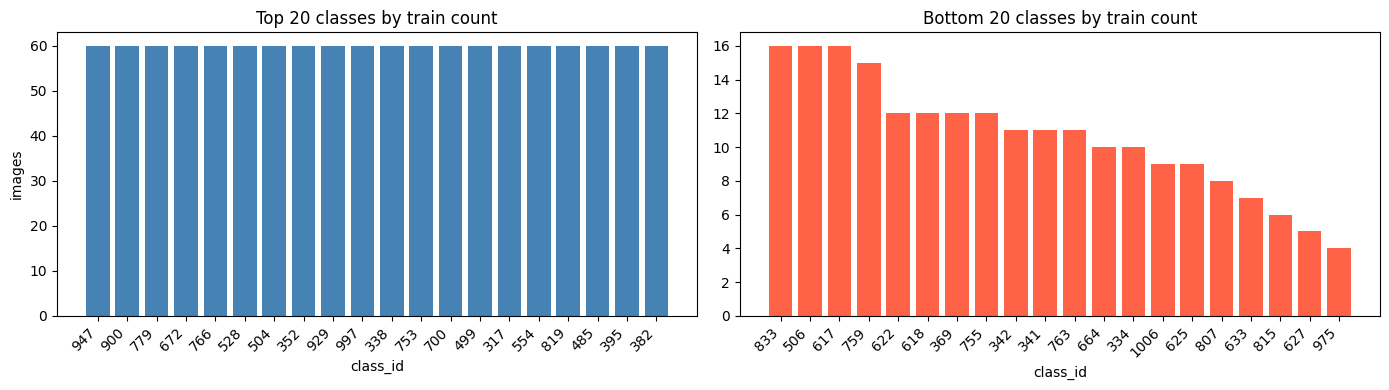

In [25]:
counts = train_df["class_id"].value_counts()
print(f"images per class — min: {counts.min()}, max: {counts.max()}, mean: {counts.mean():.1f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

top20 = counts.head(20)
axes[0].bar(range(len(top20)), top20.values, color="steelblue", width=0.6)
axes[0].set_xticks(range(len(top20)))
axes[0].set_xticklabels([str(x) for x in top20.index], rotation=45, ha="right")
axes[0].set_title("Top 20 classes by train count")
axes[0].set_xlabel("class_id")
axes[0].set_ylabel("images")

bot20 = counts.tail(20)
axes[1].bar(range(len(bot20)), bot20.values, color="tomato", width=0.6)
axes[1].set_xticks(range(len(bot20)))
axes[1].set_xticklabels([str(x) for x in bot20.index], rotation=45, ha="right")
axes[1].set_title("Bottom 20 classes by train count")
axes[1].set_xlabel("class_id")

plt.tight_layout()
out_path = IMAGES_OUT / "class_distribution.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
print(FileLink(str(out_path)))
plt.show()


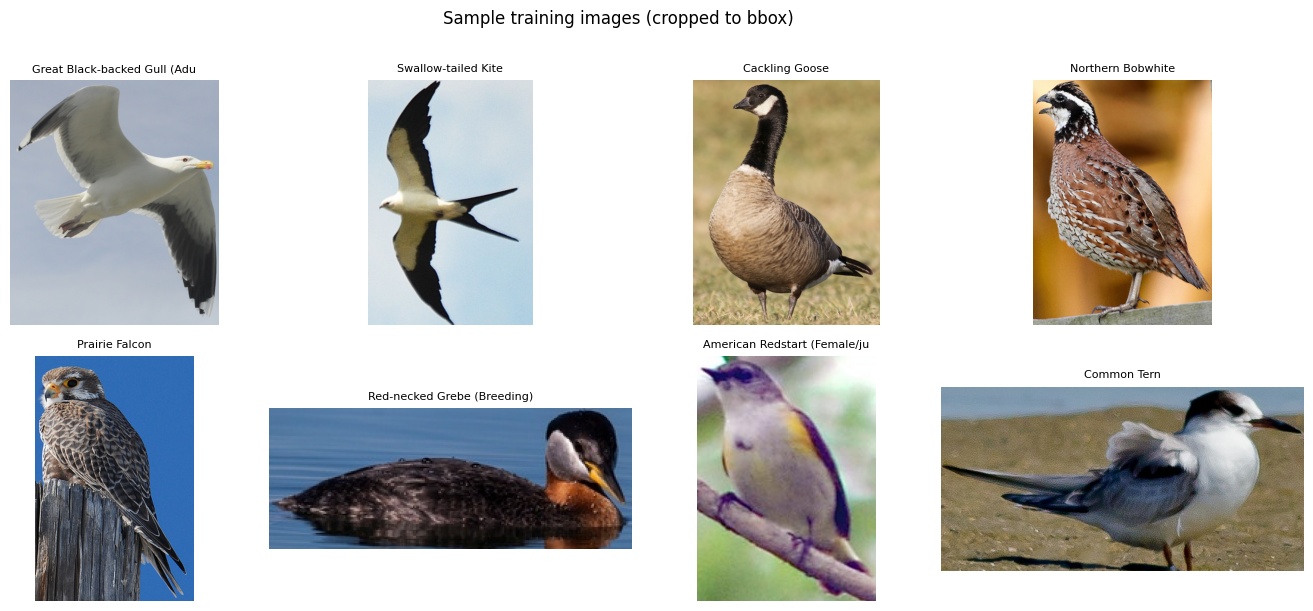

In [26]:
# Show a few sample images (raw, before train/test transforms), cropped to the bird bbox
sample_rows = train_df.groupby("class_id").first().sample(8, random_state=0)

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, (class_id, row) in zip(axes.flatten(), sample_rows.iterrows()):
    img = Image.open(os.path.join(IMAGE_DIR, row["path"])).convert("RGB")
    bx, by = max(0, int(row["x"])), max(0, int(row["y"]))
    bx2 = min(img.width,  int(row["x"] + row["w"]))
    by2 = min(img.height, int(row["y"] + row["h"]))
    if bx2 > bx and by2 > by:
        img = img.crop((bx, by, bx2, by2))
    ax.imshow(img)
    name = class_names.get(str(class_id), str(class_id))
    ax.set_title(name[:28], fontsize=8)
    ax.axis("off")

plt.suptitle("Sample training images (cropped to bbox)", y=1.01)
plt.tight_layout()
out_path = IMAGES_OUT / "sample_training_images.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
print(FileLink(str(out_path)))
plt.show()


### EDA takeaway

Classes are fairly balanced (roughly **60–100** training images each), so we skip class-weighted sampling.

Bounding boxes are tight around the bird. Cropping to the box before transforms removes a lot of cluttered background and should help the network focus on plumage and shape rather than habitat.

## 5. Dataset, transforms, and DataLoaders

### `NABirdsDataset`

For each row the dataset:

1. Opens the RGB image
2. Crops to the annotated bounding box (clamped to image bounds)
3. Applies the split-specific transform
4. Returns `(image_tensor, label)`

### Transforms

**Train** (heavy augmentation to fight overfitting on fine-grained classes):

- `RandomResizedCrop` — scale jitter
- `RandomHorizontalFlip`
- `AutoAugment(IMAGENET)` — learned augmentation policy
- ImageNet mean/std normalization (required for pretrained ResNet)

**Val / test** (deterministic eval transforms — no augmentation):

- Resize → center crop → normalize

Augmentation is train-only so validation and test numbers stay comparable.

In [28]:
class NABirdsDataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(os.path.join(self.image_dir, row["path"])).convert("RGB")

        W, H = img.size
        x  = max(0, int(row["x"]))
        y  = max(0, int(row["y"]))
        x2 = min(W, int(row["x"] + row["w"]))
        y2 = min(H, int(row["y"] + row["h"]))
        if x2 > x and y2 > y:
            img = img.crop((x, y, x2, y2))

        if self.transform:
            img = self.transform(img)

        return img, int(row["label"])


train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.AutoAugment(policy=transforms.AutoAugmentPolicy.IMAGENET),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# Shared deterministic transforms for validation and final test
eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
test_transform = eval_transform  # alias used later by Grad-CAM

train_ds = NABirdsDataset(train_df, IMAGE_DIR, transform=train_transform)
val_ds   = NABirdsDataset(val_df,   IMAGE_DIR, transform=eval_transform)
test_ds  = NABirdsDataset(test_df,  IMAGE_DIR, transform=eval_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print(
    f"Train batches: {len(train_loader)}  "
    f"Val batches: {len(val_loader)}  "
    f"Test batches: {len(test_loader)}"
)

ModuleNotFoundError: No module named 'nabirds_dataset'

## 6. Model — fine-tuned ResNet-50

We start from **ResNet-50 pretrained on ImageNet** (`IMAGENET1K_V1`).

**Why partial fine-tuning?**

- Early layers learn generic edges / textures that transfer well to bird plumage.
- With ~48k images and 555 classes, fully unfreezing the network often overfits.
- We therefore **freeze** everything except:
  - `layer3` and `layer4` (deeper residual blocks)
  - the new classification head `fc`

The original 1000-way ImageNet head is replaced with:

`Dropout(0.3) → Linear(2048 → num_classes)`

Dropout reduces co-adaptation in the new head before it has seen much NABirds data.

In [15]:
def build_model(num_classes):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    for name, param in model.named_parameters():
        if not (name.startswith("layer3") or name.startswith("layer4") or name.startswith("fc")):
            param.requires_grad = False
    model.fc = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(model.fc.in_features, num_classes),
    )
    return model

model = build_model(num_classes).to(DEVICE)
print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 186MB/s] 


Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=2048, out_features=555, bias=True)
)


## 7. Loss, optimizer, and learning-rate schedule

### Loss

`CrossEntropyLoss` with **label smoothing = 0.1**. Softening the one-hot targets helps when many species are visually near-duplicates (the model is less punished for being “almost right”).

### Differential learning rates (Adam)

| Parameter group | Learning rate | Why |
|---|---|---|
| `layer3` | `LR × 0.1` | Closest to frozen layers — update gently |
| `layer4` | `LR × 0.5` | Mid update rate |
| `fc` (new head) | `LR` | Randomly initialized — needs the largest steps |

`weight_decay=1e-4` adds mild L2 regularization.

### Schedule

1. **Linear warmup** for `WARMUP_EPOCHS` (start at 10% of each group’s LR)
2. **Cosine annealing** over the remaining epochs

Warmup avoids large early updates that can smash pretrained features.

In [18]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.Adam([
    {"params": model.layer3.parameters(), "lr": LR * 0.1},
    {"params": model.layer4.parameters(), "lr": LR * 0.5},
    {"params": model.fc.parameters(),     "lr": LR},
], weight_decay=1e-4)

warmup  = optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1, total_iters=WARMUP_EPOCHS)
cosine  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS - WARMUP_EPOCHS)
scheduler = optim.lr_scheduler.SequentialLR(optimizer, schedulers=[warmup, cosine],
                                             milestones=[WARMUP_EPOCHS])

## 8. Training and evaluation helpers

- `train_one_epoch` — standard supervised loop (forward → loss → backward → step), reporting running loss / accuracy every 100 batches.
- `evaluate` — no-grad pass that returns **loss**, **top-1**, and **top-5** accuracy. Top-5 is useful in fine-grained settings: the correct species is often among a few look-alikes.

Both helpers accumulate metrics weighted by batch size so the final averages are exact.

In [19]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = correct = total = 0

    for batch_idx, (imgs, labels) in enumerate(loader):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)

        if (batch_idx + 1) % 100 == 0:
            print(f"  step {batch_idx+1}/{len(loader)}"
                  f"  loss={total_loss/total:.4f}"
                  f"  acc={correct/total:.4f}")

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device, topk=(1, 5)):
    model.eval()
    total_loss = total = 0
    correct_k = defaultdict(int)

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * imgs.size(0)
        total += imgs.size(0)

        for k in topk:
            _, pred = outputs.topk(k, dim=1, largest=True, sorted=True)
            correct_k[k] += pred.eq(labels.view(-1, 1).expand_as(pred)).any(dim=1).sum().item()

    metrics = {f"top{k}": correct_k[k] / total for k in topk}
    metrics["loss"] = total_loss / total
    return metrics

### 8.1 Main training loop

For each epoch we:

1. Train on the train loader
2. Evaluate on the **validation** loader
3. Step the LR scheduler
4. Checkpoint weights to `models/best_model.pth` whenever **validation top-1** improves
5. **Early stop** if validation top-1 has not improved for `EARLY_STOPPING_PATIENCE` epochs

After training (or when a checkpoint already exists), we **load the best checkpoint**, evaluate **once** on the untouched official test set, and write the result to `results/final_test_metrics.json`.

**Resume / skip behavior:** if `models/best_model.pth` is already present, the epoch loop is skipped. Delete that file to force a full retrain.


In [ ]:
if MODEL_PATH.exists():
    print(f"{MODEL_PATH} found — skipping training. Delete it to retrain.")
    history = []
    best_val_top1 = None
    stopped_early = False
else:
    best_val_top1 = 0.0
    epochs_without_improvement = 0
    stopped_early = False
    history = []

    for epoch in range(1, NUM_EPOCHS + 1):
        t0 = time.time()
        print(f"\nEpoch {epoch}/{NUM_EPOCHS}")

        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        val_metrics = evaluate(model, val_loader, criterion, DEVICE)
        scheduler.step()

        elapsed = time.time() - t0
        print(
            f"  train loss={train_loss:.4f}  acc={train_acc:.4f}"
            f"  |  val loss={val_metrics['loss']:.4f}"
            f"  top1={val_metrics['top1']:.4f}"
            f"  top5={val_metrics['top5']:.4f}"
            f"  ({elapsed:.0f}s)"
        )

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_metrics["loss"],
            "val_top1": val_metrics["top1"],
            "val_top5": val_metrics["top5"],
            "elapsed_s": round(elapsed),
        })

        if val_metrics["top1"] > best_val_top1:
            best_val_top1 = val_metrics["top1"]
            epochs_without_improvement = 0
            torch.save(model.state_dict(), MODEL_PATH)
            print(f"  saved best model → {MODEL_PATH} (val top1={best_val_top1:.4f})")
        else:
            epochs_without_improvement += 1
            print(
                f"  no val improvement for {epochs_without_improvement}/"
                f"{EARLY_STOPPING_PATIENCE} epoch(s)"
            )
            if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
                stopped_early = True
                print(
                    f"\nEarly stopping at epoch {epoch} "
                    f"(best val top-1: {best_val_top1:.4f})"
                )
                break

    if not stopped_early:
        print(f"\nTraining done. Best val top-1: {best_val_top1:.4f}")

# Final test evaluation — single pass on the untouched official test split
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE, weights_only=True))
test_metrics = evaluate(model, test_loader, criterion, DEVICE)
print(
    f"\nFinal test (best val checkpoint):"
    f"  loss={test_metrics['loss']:.4f}"
    f"  top1={test_metrics['top1']:.4f}"
    f"  top5={test_metrics['top5']:.4f}"
)

final_test_record = {
    "loss": float(test_metrics["loss"]),
    "top1": float(test_metrics["top1"]),
    "top5": float(test_metrics["top5"]),
    "best_val_top1": None if best_val_top1 is None else float(best_val_top1),
    "stopped_early": stopped_early,
    "num_epochs_ran": len(history) if history else None,
    "seed": SEED,
    "val_fraction": VAL_FRACTION,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
}
with open(METRICS_PATH, "w") as f:
    json.dump(final_test_record, f, indent=2)
print(f"Wrote {METRICS_PATH}")


## 9. Training curves

We prefer in-memory `history` from a fresh run (and overwrite `results/training_history.csv`). If training was skipped, we fall back to a previously saved CSV.

Left plot: train vs **validation** loss.
Right plot: train accuracy vs validation **top-1** / **top-5**.

The **final test** metrics are saved in `results/final_test_metrics.json` — copy that file (and the PNGs under `images/`) into GitHub so others can see results without retraining.


In [ ]:
if history:
    hist_df = pd.DataFrame(history)
    hist_df.to_csv(HISTORY_PATH, index=False)
elif HISTORY_PATH.exists():
    hist_df = pd.read_csv(HISTORY_PATH)
else:
    hist_df = None

if hist_df is not None:
    display(hist_df)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(hist_df["epoch"], hist_df["train_loss"], label="train")
    axes[0].plot(hist_df["epoch"], hist_df["val_loss"],   label="val")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Loss")
    axes[0].legend()

    axes[1].plot(hist_df["epoch"], hist_df["train_acc"], label="train")
    axes[1].plot(hist_df["epoch"], hist_df["val_top1"],  label="val top-1")
    axes[1].plot(hist_df["epoch"], hist_df["val_top5"],  label="val top-5")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    out_path = IMAGES_OUT / "loss_and_accuracy.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    print(FileLink(str(out_path)))
    plt.show()
else:
    print("No training history available.")

if METRICS_PATH.exists():
    with open(METRICS_PATH) as f:
        saved = json.load(f)
    print(
        f"Reported test metrics ({METRICS_PATH}) — "
        f"top1={saved['top1']:.4f}  top5={saved['top5']:.4f}  loss={saved['loss']:.4f}"
    )
else:
    print(
        f"Reported test metrics — top1={test_metrics['top1']:.4f}  "
        f"top5={test_metrics['top5']:.4f}  loss={test_metrics['loss']:.4f}"
    )


## 10. Per-class accuracy (official test set)

Using the **best validation checkpoint**, we predict every image in the untouched official test set and compute accuracy per class.

Results are saved to `per_class_accuracy.csv`. The **10 easiest** and **10 hardest** species are shown below — hard classes are good candidates for Grad-CAM next.

In [ ]:
idx_to_class = {v: k for k, v in class_to_idx.items()}
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE, weights_only=True))
model.eval()

class_correct = defaultdict(int)
class_total   = defaultdict(int)

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        preds = model(imgs).argmax(dim=1)
        for pred, label in zip(preds, labels):
            class_total[label.item()] += 1
            class_correct[label.item()] += int(pred == label)

per_class = [
    {
        "class_id":   idx_to_class[i],
        "class_name": class_names.get(str(idx_to_class[i]), "?"),
        "correct":    class_correct[i],
        "total":      class_total[i],
        "accuracy":   class_correct[i] / class_total[i] if class_total[i] else 0,
    }
    for i in range(num_classes)
    if class_total[i] > 0
]
per_class_df = pd.DataFrame(per_class).sort_values("accuracy", ascending=False)
per_class_df.to_csv(PER_CLASS_PATH, index=False)
print(f"Wrote {PER_CLASS_PATH}")

print("Top-10 easiest:")
display(per_class_df.head(10)[["class_name", "accuracy", "total"]])
print("\nTop-10 hardest:")
display(per_class_df.tail(10)[["class_name", "accuracy", "total"]])


## 11. Grad-CAM analysis

[Grad-CAM](https://arxiv.org/abs/1610.02391) highlights which spatial regions most influence a class prediction.

**How this implementation works:**

1. Hook the last convolutional block (`model.layer4[-1]`) to capture activations and gradients
2. Globally average the gradients → channel importance weights
3. Weighted-sum the activations, apply ReLU, and normalize to `[0, 1]`
4. Upsample the heatmap onto the input image

We also project NABirds **part landmarks** (beak, eye, nape, …) onto the cropped/resized view so you can judge whether the model focuses on biologically meaningful areas.

Comparing the **10 hardest** vs **10 easiest** classes is a quick qualitative check: easy classes often show tight focus on the bird; hard ones may fire on background or miss tiny diagnostic cues.

In [ ]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self._act = self._grad = None
        target_layer.register_forward_hook(self._fwd)
        target_layer.register_full_backward_hook(self._bwd)

    def _fwd(self, _, __, output):
        self._act = output.detach()

    def _bwd(self, _, __, grad_output):
        self._grad = grad_output[0].detach()

    def __call__(self, x, class_idx):
        self.model.zero_grad()
        logits = self.model(x)
        logits[0, class_idx].backward()
        weights = self._grad.mean(dim=(2, 3), keepdim=True)
        cam = torch.relu((weights * self._act).sum(dim=1)).squeeze()
        cam = cam.cpu().float().numpy()
        if cam.max() > cam.min():
            cam = (cam - cam.min()) / (cam.max() - cam.min())
        return cam


_IMG_MEAN = np.array([0.485, 0.456, 0.406])
_IMG_STD  = np.array([0.229, 0.224, 0.225])

def _denorm(tensor):
    # Undo ImageNet normalization for display
    img = tensor.squeeze().permute(1, 2, 0).cpu().numpy()
    return np.clip(_IMG_STD * img + _IMG_MEAN, 0, 1)

_PART_COLORS = [
    "#FF3333", "#FF9900", "#FFE800", "#33FF57", "#00CCFF",
    "#0044FF", "#AA00FF", "#FF00AA", "#00FFCC", "#FF6600", "#99FF00",
]

def _project_part(px, py, bbox_x, bbox_y, bbox_w, bbox_h, display=224):
    # Map a full-image part coordinate into the test-transform crop space
    cx, cy = px - bbox_x, py - bbox_y
    if cx < 0 or cy < 0 or cx > bbox_w or cy > bbox_h:
        return None
    scale = 256.0 / min(bbox_w, bbox_h)
    new_w, new_h = bbox_w * scale, bbox_h * scale
    cx = cx * scale - (new_w - display) / 2
    cy = cy * scale - (new_h - display) / 2
    if not (0 <= cx <= display and 0 <= cy <= display):
        return None
    return cx, cy

### 11.1 Plot helper

For each selected class we show up to `n_per_class` test images as **(original + part dots | Grad-CAM overlay)** pairs.

In [ ]:
def plot_gradcam(class_ids, title, n_per_class=2, save_path=None):
    hard_labels = [class_to_idx[cid] for cid in class_ids if cid in class_to_idx]
    samples = (
        test_df[test_df["label"].isin(hard_labels)]
        .groupby("label", group_keys=False)
        .head(n_per_class)
    )

    n = len(samples)
    ncols = 4
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols * 2, figsize=(ncols * 5, nrows * 3.5))
    axes = axes.flatten()

    model.eval()
    ax_i = 0
    for _, row in samples.iterrows():
        img_pil = Image.open(os.path.join(IMAGE_DIR, row["path"])).convert("RGB")
        W, H = img_pil.size
        bx  = max(0, int(row["x"]))
        by  = max(0, int(row["y"]))
        bx2 = min(W, int(row["x"] + row["w"]))
        by2 = min(H, int(row["y"] + row["h"]))
        bbox_w, bbox_h = bx2 - bx, by2 - by
        if bbox_w > 0 and bbox_h > 0:
            img_pil = img_pil.crop((bx, by, bx2, by2))

        tensor = test_transform(img_pil).unsqueeze(0).to(DEVICE)
        label  = int(row["label"])

        with torch.enable_grad():
            cam = gradcam(tensor, label)

        img_np = _denorm(tensor)
        h, w   = img_np.shape[:2]
        cam_up = np.array(
            Image.fromarray((cam * 255).astype(np.uint8)).resize((w, h), Image.BILINEAR)
        ) / 255.0

        name  = class_names.get(str(idx_to_class.get(label, "")), "?")
        tlabel = name if len(name) <= 22 else name[:21] + "..."

        axes[ax_i].imshow(img_np)
        axes[ax_i].set_title(tlabel, fontsize=8)
        axes[ax_i].axis("off")

        img_parts = part_locs.get(row["image_id"], {})
        for pid, (px, py, vis) in img_parts.items():
            if not vis:
                continue
            projected = _project_part(px, py, bx, by, bbox_w, bbox_h)
            if projected is None:
                continue
            cx, cy = projected
            color = _PART_COLORS[int(pid) % len(_PART_COLORS)]
            axes[ax_i].plot(cx, cy, "o", color=color, markersize=5,
                            markeredgecolor="white", markeredgewidth=0.6)
            axes[ax_i].text(cx + 3, cy - 3, part_names.get(pid, pid),
                            fontsize=5, color=color,
                            bbox=dict(boxstyle="round,pad=0.1", fc="black", alpha=0.4, lw=0))
        ax_i += 1

        axes[ax_i].imshow(img_np)
        axes[ax_i].imshow(cam_up, cmap="jet", alpha=0.45)
        axes[ax_i].set_title("Grad-CAM", fontsize=8)
        axes[ax_i].axis("off")
        ax_i += 1

    for i in range(ax_i, len(axes)):
        axes[i].axis("off")

    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(FileLink(str(save_path)))
    plt.show()


### 11.2 Hardest classes

Load part annotations, attach Grad-CAM to `layer4[-1]`, and visualize the 10 lowest-accuracy species.

In [ ]:
part_locs  = load_part_locations(DATASET_PATH)
part_names = load_part_names(DATASET_PATH)
gradcam    = GradCAM(model, model.layer4[-1])

hard_ids = per_class_df.tail(10)["class_id"].tolist()
plot_gradcam(
    hard_ids,
    "Grad-CAM — 10 Hardest Classes",
    save_path=IMAGES_OUT / "gradcam_hardest.png",
)


### 11.3 Easiest classes

Same visualization for the 10 highest-accuracy species — a useful contrast with the hard set above.

In [ ]:
easy_ids = per_class_df.head(10)["class_id"].tolist()
plot_gradcam(
    easy_ids,
    "Grad-CAM — 10 Easiest Classes",
    save_path=IMAGES_OUT / "gradcam_easiest.png",
)


## 12. Summary

| Piece | Choice |
|---|---|
| Task | Fine-grained bird species classification (NABirds, 555 classes) |
| Split | Official train/test; **10% of train** held out as stratified validation |
| Backbone | ImageNet-pretrained ResNet-50 |
| Fine-tuning | Unfreeze `layer3`, `layer4`, and a new Dropout + Linear head |
| Preprocessing | Crop to bird bbox; ImageNet-normalized 224×224 inputs |
| Regularization | AutoAugment, dropout, label smoothing, weight decay |
| Optimization | Adam with differential LRs + warmup + cosine decay |
| Model selection | Best **validation** top-1 → `models/best_model.pth` |
| Early stopping | Stop after `EARLY_STOPPING_PATIENCE` epochs without val improvement |
| Reported metrics | Single evaluation on untouched official **test** → `results/final_test_metrics.json` |
| Interpretability | Grad-CAM on `layer4` with part-landmark overlays |

**Artifacts** (download from Kaggle Output and commit to GitHub):

| Path | Contents |
|---|---|
| `images/` | EDA plots, loss curves, Grad-CAM figures |
| `models/best_model.pth` | Best validation checkpoint |
| `results/` | `final_test_metrics.json`, `training_history.csv`, `per_class_accuracy.csv` |

Possible next steps: try a stronger backbone (e.g. EfficientNet / ViT), unfreeze more layers with a lower LR, or add mixup / cutmix for the hardest look-alike species.
